# 🚀 AutoGluon: Clasificación con AutoGluon
Este cuaderno demuestra cómo **AutoGluon** simplifica drásticamente el proceso de Machine Learning. En lugar de crear, escalar y probar modelos manualmente (como en Scikit-Learn), AutoGluon entrena múltiples modelos de última generación y los combina automáticamente.


## 💡 **Marco Teórico: AutoGluon para Clasificación**

AutoGluon automatiza los flujos de modelado para clasificación binaria o multiclase de forma eficiente y robusta.

### **Métricas de Clasificación en AutoML:**
- **Exactitud (Accuracy):** La proporción de predicciones correctas entre el total de predicciones. Por defecto, AutoGluon suele optimizar para exactitud si no se especifica otra métrica.
- **Precisión (Precision):** La capacidad del modelo de no etiquetar como positiva una muestra que es negativa ($TP / (TP + FP)$).
- **Recall (Sensibilidad):** La capacidad del modelo para encontrar todas las muestras positivas ($TP / (TP + FN)$).
- **F1-Score:** El promedio armónico entre precisión y recall. Es de especial utilidad cuando existe un fuerte desbalance de clases.

### **Ensemble L2 Stacking (Apilamiento de Modelos):**
AutoGluon entrena múltiples modelos individuales (como árboles de decisión, redes neuronales y bosques aleatorios) y luego combina sus predicciones. El apilamiento (Stacking) utiliza las predicciones de estos modelos como variables de entrada (meta-features) para alimentar a un modelo de nivel superior (meta-modelo), maximizando la exactitud del ensamble final.


###https://autogluon.com/


In [1]:
!pip install autogluon -q


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 542.8 kB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.5/259.5 kB 2.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 227.6/227.6 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.9/98.9 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 452.1/452.1 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.2/515.2 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.8/244.8 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.4/74.4 kB 4.5 MB/s eta 0:00

In [2]:
!pip install autogluon.tabular[all]

In [3]:
##!pip install autogluon.text
##!pip install autogluon.vision
##!pip install autogluon.timeseries

In [4]:
import pandas as pd
from autogluon.tabular import TabularPredictor
from sklearn.model_selection import train_test_split


## 1. Carga de Datos
Leemos directamente el CSV. A diferencia de otros flujos, NO necesitamos separar `X` e `y` manualmente antes de dividir los datos.

In [5]:
url = 'https://raw.githubusercontent.com/cristiandarioortegayubro/BA/main/Datasets/Clientes.csv'
datos = pd.read_csv(url)
datos.head()


,ID,Trabajo,Edad,Salario,Compra
0,15624510,1,19,19000,No
1,15810944,1,35,20000,No
2,15668575,0,26,43000,No
3,15603246,0,27,57000,No
4,15804002,1,19,76000,No


In [6]:
datos.to_csv('clientes.csv', index=False)

In [7]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   ID       400 non-null    int64 
 1   Trabajo  400 non-null    int64 
 2   Edad     400 non-null    int64 
 3   Salario  400 non-null    int64 
 4   Compra   400 non-null    object
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


## 2. División de Entrenamiento y Prueba
Separamos las filas. `train_data` será para entrenar y `test_data` para probar. ¡Mantenemos todas las columnas juntas!

In [8]:
# Separamos el 80% para entrenar y el 20% para probar
train_data, test_data = train_test_split(datos, test_size=0.2, random_state=42)
print(f'Datos de entrenamiento: {train_data.shape}')
print(f'Datos de prueba: {test_data.shape}')


Datos de entrenamiento: (320, 5)
Datos de prueba: (80, 5)


## 3. Magia de AutoGluon: Entrenamiento Automático
Aquí está la magia. Solo le decimos cuál es la columna que queremos predecir (`compra`) y llamamos a `.fit()`. AutoGluon escalará los datos, tratará los valores nulos y entrenará desde Árboles hasta Redes Neuronales por nosotros.

In [10]:
import time

columna_objetivo = 'Compra'

print("⏳ Entrenando AutoGluon de forma ultra rápida...")
tiempo_inicio = time.time()

# Entrenamos en modo rápido y silenciamos el proceso interno (verbosity=0)
predictor = TabularPredictor(label=columna_objetivo, eval_metric='accuracy').fit(
    train_data,
    presets='medium_quality',
    time_limit=60,
    verbosity=0
)

tiempo_total = time.time() - tiempo_inicio
metricas = predictor.evaluate(test_data, silent=True)
leaderboard = predictor.leaderboard(test_data, silent=True)

# --- SALIDA ULTRA LIMPIA ---
print("\n" + "="*40)
print(f"⏱️  Tiempo: {tiempo_total:.1f} seg | 🤖 Líder: {predictor.model_best}")
print("="*40)
print(f"• Accuracy:  {metricas.get('accuracy', 0):.4f}")
print(f"• Precision: {metricas.get('precision', 0):.4f}")
print(f"• Recall:    {metricas.get('recall', 0):.4f}")
print(f"• F1-Score:  {metricas.get('f1', 0):.4f}")
print("-"*40)

print("🏆 TOP 3 MODELOS:")
for idx, fila in leaderboard.head(3).iterrows():
    print(f" {idx+1}. {fila['model']} -> {fila['score_test']:.4f}")
print("="*40)

No path specified. Models will be saved in: "AutogluonModels/ag-20260520_220439"


⏳ Entrenando AutoGluon de forma ultra rápida...

⏱️  Tiempo: 16.5 seg | 🤖 Líder: WeightedEnsemble_L2
• Accuracy:  0.9125
• Precision: 0.8889
• Recall:    0.8571
• F1-Score:  0.8727
----------------------------------------
🏆 TOP 5 MODELOS:
 1. CatBoost -> 0.9250
 2. LightGBM -> 0.9250
 3. NeuralNetTorch -> 0.9250


In [11]:
import time
from autogluon.tabular import TabularPredictor

columna_objetivo = 'Compra'

print("⏳ Entrenando AutoGluon con 10 modelos específicos...")
tiempo_inicio = time.time()

# Definimos los 10 modelos exactos que queremos entrenar
diez_modelos = {
    'LR': {},       # 1. Regresión Logística (vía Scikit-learn)
    'KNN': {},      # 2. K-Nearest Neighbors
    'RF': {},       # 3. Random Forest
    'XT': {},       # 4. Extra Trees (Árboles extremadamente aleatorios)
    'GBM': {},      # 5. LightGBM (Gradiente descrita estándar)
    'CAT': {},      # 6. CatBoost (Excelente con categorías)
    'XGB': {},      # 7. XGBoost (Ultra rápido y preciso)
    'NN_TORCH': {}, # 8. Red Neuronal Profunda (PyTorch)
    'FASTAI': {},   # 9. Red Neuronal estilo FastAI
    'FASTTEXT': {}  # 10. Modelo de texto rápido (útil si hay texto libre, si no, actúa como baseline)
}

# Entrenamos forzando la lista de los 10 modelos
predictor = TabularPredictor(label=columna_objetivo, eval_metric='accuracy').fit(
    train_data,
    hyperparameters=diez_modelos,
    time_limit=90,                # Le subí a 90s para asegurar que dé tiempo de meter los 10
    verbosity=0
)

tiempo_total = time.time() - tiempo_inicio

# Forzamos el cálculo de las métricas secundarias si no vienen en evaluate
metricas = predictor.evaluate(test_data, silent=True)
leaderboard = predictor.leaderboard(test_data, silent=True)

# --- SALIDA ULTRA LIMPIA ---
print("\n" + "="*40)
print(f"⏱️  Tiempo: {tiempo_total:.1f} seg | 🤖 Líder: {predictor.model_best}")
print("="*40)
print(f"• Accuracy:  {metricas.get('accuracy', 0):.4f}")
print(f"• Precision: {metricas.get('precision', 0):.4f}")
print(f"• Recall:    {metricas.get('recall', 0):.4f}")
print(f"• F1-Score:  {metricas.get('f1', 0):.4f}")
print("-"*40)

print("🏆 TOP 3 MODELOS (De los 10 solicitados):")
# Reseteamos el índice del leaderboard para que idx corresponda al orden real (0, 1, 2)
leaderboard_top = leaderboard.head(3).reset_index()
for idx, fila in leaderboard_top.iterrows():
    print(f" {idx+1}. {fila['model']} -> {fila['score_test']:.4f}")
print("="*40)

No path specified. Models will be saved in: "AutogluonModels/ag-20260520_221012"


⏳ Entrenando AutoGluon con 10 modelos específicos...

⏱️  Tiempo: 16.4 seg | 🤖 Líder: WeightedEnsemble_L2
• Accuracy:  0.9125
• Precision: 0.8889
• Recall:    0.8571
• F1-Score:  0.8727
----------------------------------------
🏆 TOP 3 MODELOS (De los 10 solicitados):
 1. LightGBM -> 0.9250
 2. CatBoost -> 0.9250
 3. NeuralNetTorch -> 0.9250


## 4. Evaluación y Resumen de Modelos
Veamos la tabla de posiciones (leaderboard) para ver qué algoritmos funcionaron mejor.

📊 Generando Evaluación Nativa de AutoGluon...

 🎯 REPORTE COMPLETO DE MÉTRICAS (AUTOGLUON)
 • Accuracy          : 0.9125
 • Balanced Accuracy : 0.8997
 • Mcc               : 0.8064
 • Roc Auc           : 0.9650
 • F1                : 0.8727
 • Precision         : 0.8889
 • Recall            : 0.8571

🧠 Calculando impacto de las variables en el negocio...


/tmp/ipykernel_4484/598141732.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importancia['importance'], y=importancia.index, palette='viridis')


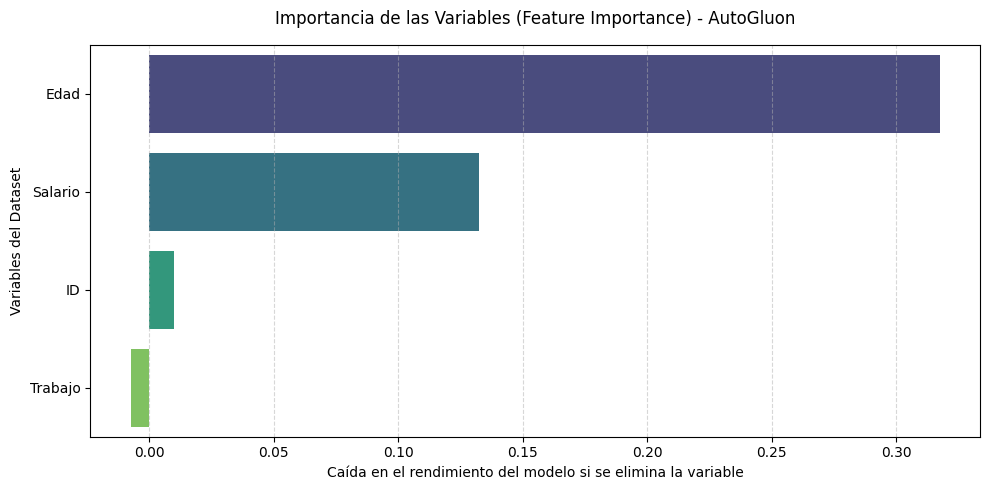

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("📊 Generando Evaluación Nativa de AutoGluon...\n")

# 1. Obtener el diccionario completo de métricas que calcula AutoGluon por defecto
metricas_nativas = predictor.evaluate(test_data, silent=True)

print("="*45)
print(" 🎯 REPORTE COMPLETO DE MÉTRICAS (AUTOGLUON)")
print("="*45)
for metrica, valor in metricas_nativas.items():
    # Traducimos visualmente los nombres internos a algo más limpio
    nombre_limpio = metrica.replace('_', ' ').title()
    print(f" • {nombre_limpio:<18}: {valor:.4f}")
print("="*45)

# 2. Calcular la Importancia de las Variables (Feature Importance) nativa de AutoGluon
print("\n🧠 Calculando impacto de las variables en el negocio...")
importancia = predictor.feature_importance(test_data, silent=True)

# 3. Graficar la importancia de las variables de forma limpia
plt.figure(figsize=(10, 5))
sns.barplot(x=importancia['importance'], y=importancia.index, palette='viridis')
plt.title('Importancia de las Variables (Feature Importance) - AutoGluon', fontsize=12, pad=15)
plt.xlabel('Caída en el rendimiento del modelo si se elimina la variable', fontsize=10)
plt.ylabel('Variables del Dataset', fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [ ]:
predictor.leaderboard(test_data)


,model,score_test,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,LightGBM,0.9250,0.875000,accuracy,0.002546,0.001066,0.406015,0.002546,0.001066,0.406015,1,True,2
1,CatBoost,0.9250,0.875000,accuracy,0.003851,0.000824,0.359625,0.003851,0.000824,0.359625,1,True,5
2,NeuralNetTorch,0.9250,0.906250,accuracy,0.009726,0.015540,1.730282,0.009726,0.015540,1.730282,1,True,10
3,ExtraTreesGini,0.9250,0.843750,accuracy,0.100347,0.098212,0.825938,0.100347,0.098212,0.825938,1,True,6
4,LightGBMXT,0.9125,0.890625,accuracy,0.004930,0.001303,0.424512,0.004930,0.001303,0.424512,1,True,1
5,NeuralNetFastAI,0.9125,0.921875,accuracy,0.019974,0.011496,2.462829,0.019974,0.011496,2.462829,1,True,8
6,WeightedEnsemble_L2,0.9125,0.921875,accuracy,0.023298,0.012924,2.615020,0.003325,0.001428,0.152191,2,True,12
7,ExtraTreesEntr,0.9125,0.843750,accuracy,0.100248,0.087977,0.822690,0.100248,0.087977,0.822690,1,True,7
8,XGBoost,0.9000,0.875000,accuracy,0.014294,0.006458,0.218090,0.014294,0.006458,0.218090,1,True,9
9,RandomForestEntr,0.9000,0.859375,accuracy,0.102854,0.088956,0.846649,0.102854,0.088956,0.846649,1,True,4


## 5. Predicción
Usamos el mejor modelo ensamblado para generar predicciones sobre los datos de prueba.

In [ ]:
# Obtenemos las predicciones (eliminando la columna objetivo de X_test)
y_pred = predictor.predict(test_data.drop(columns=[columna_objetivo]))
y_pred.head()


,Compra
209,Si
280,No
33,No
210,Si
93,No


📊 Extrayendo métricas de AutoGluon y generando Dashboard Gráfico...



/tmp/ipykernel_4484/2819560917.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importancia['importance'], y=importancia.index, palette='viridis', ax=axes[1, 1])
/tmp/ipykernel_4484/2819560917.py:63: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


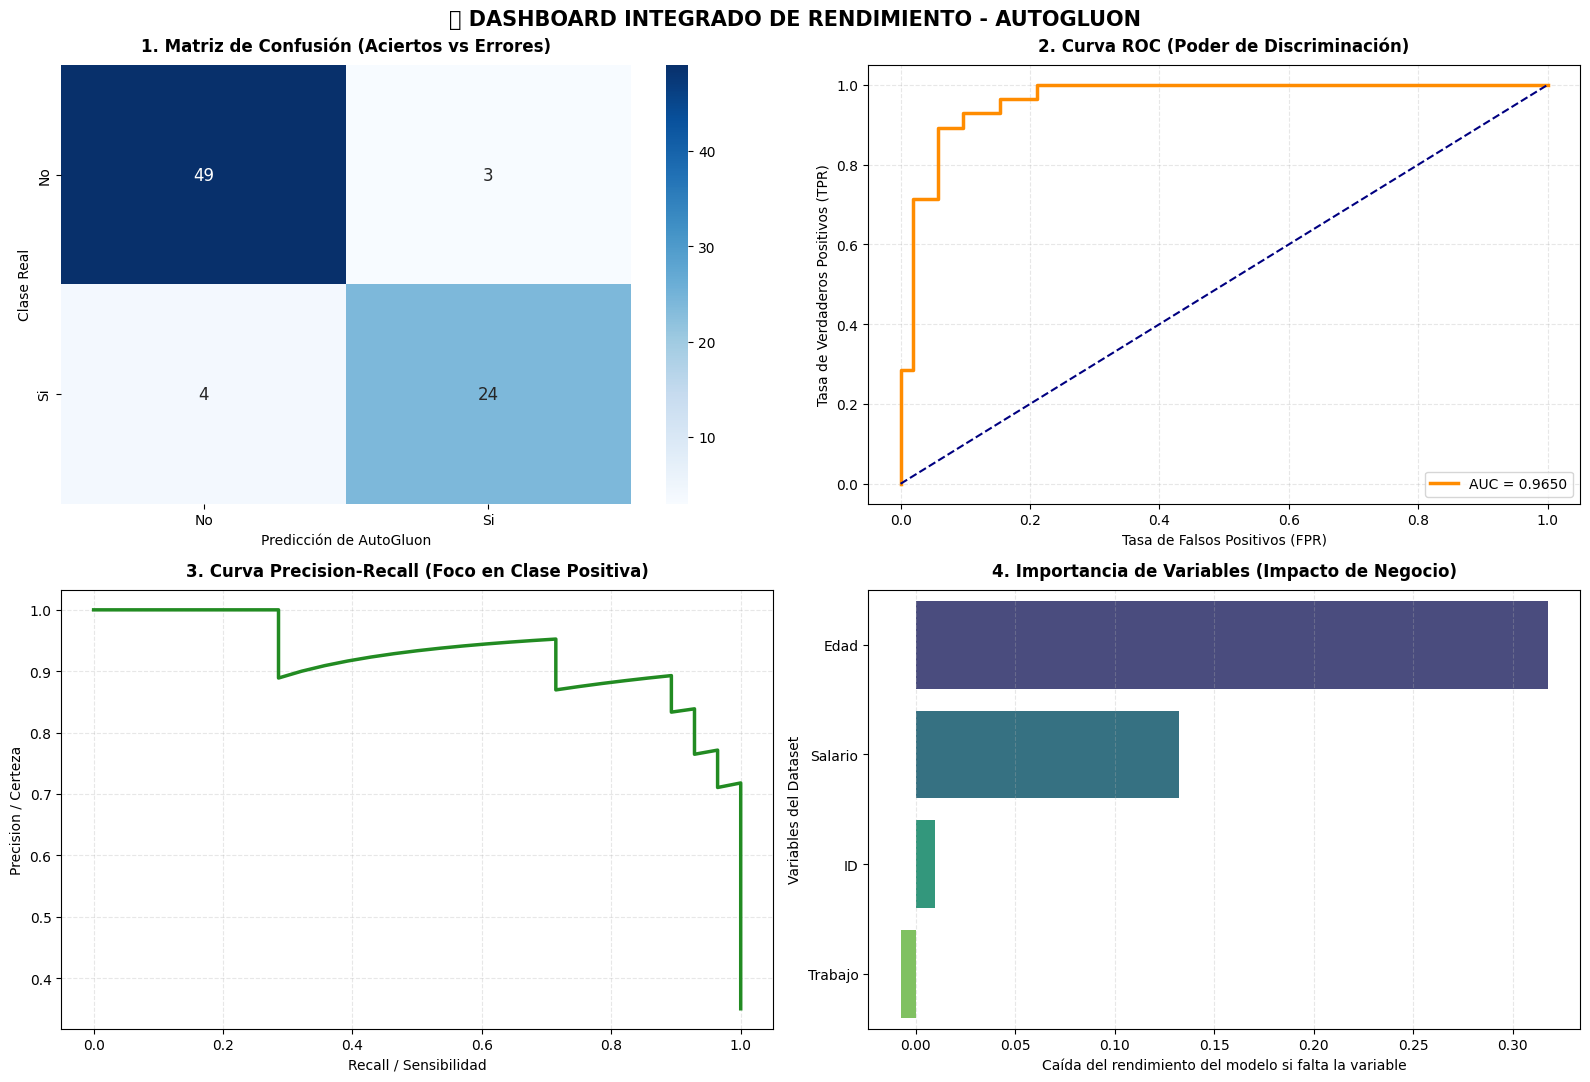

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve

print("📊 Extrayendo métricas de AutoGluon y generando Dashboard Gráfico...\n")

# 1. OBTENER PREDICCIONES Y PROBABILIDADES DIRECTAMENTE DE AUTOGLUON
X_test = test_data.drop(columns=[columna_objetivo])
y_test_real = test_data[columna_objetivo]

# AutoGluon nos da las etiquetas finales y las probabilidades de cada clase
y_pred = predictor.predict(X_test)
y_pred_proba = predictor.predict_proba(X_test)

# Identificar de forma automática las clases (ej: [0, 1] o ['No', 'Si'])
clases = predictor.class_labels
clase_positiva = clases[1]
y_pred_proba_pos = y_pred_proba[clase_positiva]

# Extraer la importancia de variables calculada por AutoGluon
importancia = predictor.feature_importance(test_data, silent=True)


# 2. CONSTRUIR EL DASHBOARD ANALÍTICO (Panel de 2x2)
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# --- GRÁFICO 1: MATRIZ DE CONFUSIÓN ---
cm = confusion_matrix(y_test_real, y_pred, labels=clases)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
            xticklabels=clases, yticklabels=clases, annot_kws={"size": 12})
axes[0, 0].set_title('1. Matriz de Confusión (Aciertos vs Errores)', weight='bold', pad=10)
axes[0, 0].set_xlabel('Predicción de AutoGluon')
axes[0, 0].set_ylabel('Clase Real')

# --- GRÁFICO 2: CURVA ROC ---
fpr, tpr, _ = roc_curve(y_test_real, y_pred_proba_pos, pos_label=clase_positiva)
roc_auc = auc(fpr, tpr)
axes[0, 1].plot(fpr, tpr, color='darkorange', lw=2.5, label=f'AUC = {roc_auc:.4f}')
axes[0, 1].plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--')
axes[0, 1].set_title('2. Curva ROC (Poder de Discriminación)', weight='bold', pad=10)
axes[0, 1].set_xlabel('Tasa de Falsos Positivos (FPR)')
axes[0, 1].set_ylabel('Tasa de Verdaderos Positivos (TPR)')
axes[0, 1].legend(loc="lower right")
axes[0, 1].grid(True, linestyle='--', alpha=0.3)

# --- GRÁFICO 3: CURVA PRECISION-RECALL ---
precision, recall, _ = precision_recall_curve(y_test_real, y_pred_proba_pos, pos_label=clase_positiva)
axes[1, 0].plot(recall, precision, color='forestgreen', lw=2.5)
axes[1, 0].set_title('3. Curva Precision-Recall (Foco en Clase Positiva)', weight='bold', pad=10)
axes[1, 0].set_xlabel('Recall / Sensibilidad')
axes[1, 0].set_ylabel('Precision / Certeza')
axes[1, 0].grid(True, linestyle='--', alpha=0.3)

# --- GRÁFICO 4: IMPORTANCIA DE VARIABLES (NATIVA DE AUTOGLUON) ---
sns.barplot(x=importancia['importance'], y=importancia.index, palette='viridis', ax=axes[1, 1])
axes[1, 1].set_title('4. Importancia de Variables (Impacto de Negocio)', weight='bold', pad=10)
axes[1, 1].set_xlabel('Caída del rendimiento del modelo si falta la variable')
axes[1, 1].set_ylabel('Variables del Dataset')
axes[1, 1].grid(True, axis='x', linestyle='--', alpha=0.3)

# Ajustes generales de presentación
plt.suptitle('🚀 DASHBOARD INTEGRADO DE RENDIMIENTO - AUTOGLUON', fontsize=15, weight='bold', y=0.98)
plt.tight_layout()
plt.show()